In [ ]:
""" element to cartesian coordinates conversion and plotting of Hill sphere in AU """

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_hill_sphere_au():
    # --- 定数設定 (無次元化) ---
    # 距離の基準: 1.0 = 1 AU (太陽-地球間距離)
    a_AU = 1.0

    # 質量の基準
    M_sun = 1.989e30    # 太陽質量 (kg)
    M_earth = 5.972e24  # 地球質量 (kg)

    # ヒル球の半径計算 (単位: AU)
    # 公式: r = a * (m / 3M)^(1/3)
    r_hill_au = a_AU * (M_earth / (3 * M_sun))**(1/3)

    print(f"ヒル球の半径: {r_hill_au:.5f} AU")

    # --- 参考データ: 月の軌道 ---
    # 月までの距離: 約384,400 km
    # 1 AU: 約149,600,000 km
    km_per_au = 1.496e8
    r_moon_au = 384400 / km_per_au

    # --- プロット作成 ---
    fig, ax = plt.subplots(figsize=(8, 8))

    # 1. ヒル球 (Hill Sphere)
    hill_circle = patches.Circle((0, 0), r_hill_au,
                                 color='green', alpha=0.1,
                                 label='ヒル球 (Hill Sphere)')
    ax.add_patch(hill_circle)
    ax.add_patch(patches.Circle((0, 0), r_hill_au, color='green', fill=False, linestyle='--'))

    # 2. 月の軌道 (Moon Orbit)
    moon_circle = patches.Circle((0, 0), r_moon_au,
                                 edgecolor='gray', linestyle=':', fill=False,
                                 label='月の軌道 (Moon Orbit)')
    ax.add_patch(moon_circle)

    # 3. 地球 (Earth)
    ax.plot(0, 0, marker='o', color='blue', markersize=8, label='地球 (Earth)')

    # 4. ラグランジュ点 L1, L2 (近似)
    ax.scatter([-r_hill_au, r_hill_au], [0, 0], color='red', marker='x', label='L1 / L2 (近似)')

    # 5. 太陽方向の矢印
    ax.annotate('太陽の方向 (-1.0 AU)', xy=(-r_hill_au, 0), xytext=(-r_hill_au*1.4, 0),
                arrowprops=dict(facecolor='orange', arrowstyle='->', color='orange'),
                ha='right', va='center', color='darkorange', weight='bold')

    # --- グラフの装飾 ---
    limit = r_hill_au * 1.5
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')

    ax.set_xlabel('地球からの距離 (AU)')
    ax.set_ylabel('地球からの距離 (AU)')
    ax.set_title(f'地球のヒル球 (無次元化距離)\n半径 $r_{{Hill}} \\approx {r_hill_au:.5f}$ AU', fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_hill_sphere_au()


In [ ]:
""" ゼロ速度曲線 (ZVC) と運動不可能領域のプロット（天体2周辺のズーム付き）"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def effective_potential(x, y, mu):
    """
    制限三体問題の有効ポテンシャル
    mu: 質量比パラメータ（小さい天体の質量 / 全質量）
    """
    # 二つの主天体の位置
    r1 = np.sqrt((x + mu) ** 2 + y**2)
    r2 = np.sqrt((x - 1 + mu) ** 2 + y**2)

    # ゼロ除算を避ける
    r1 = np.maximum(r1, 1e-10)
    r2 = np.maximum(r2, 1e-10)

    # 有効ポテンシャル
    U = 0.5 * (x**2 + y**2) + (1 - mu) / r1 + mu / r2

    return U


def plot_zero_velocity_curves(mu=0.01, jacobi_constants=None):
    """
    ゼロ速度曲線を描画（天体2周辺のズーム付き）
    mu: 質量比（例: 地球-月系なら約0.012）
    jacobi_constants: ヤコビ定数のリスト
    """
    # グリッドの作成（全体図用）
    x = np.linspace(-1.5, 1.5, 500)
    y = np.linspace(-1.5, 1.5, 500)
    X, Y = np.meshgrid(x, y)

    # 有効ポテンシャルの計算
    U = effective_potential(X, Y, mu)

    # ズーム領域用のグリッド（天体2周辺）
    zoom_range = 0.01  # ズーム範囲
    x_zoom = np.linspace(1 - mu - zoom_range, 1 - mu + zoom_range, 300)
    y_zoom = np.linspace(-zoom_range, zoom_range, 300)
    X_zoom, Y_zoom = np.meshgrid(x_zoom, y_zoom)
    U_zoom = effective_potential(X_zoom, Y_zoom, mu)

    # ヤコビ定数の設定（デフォルト値）
    if jacobi_constants is None:
        jacobi_constants = [3.0, 3.2, 3.4, 3.6, 3.8]

    # プロットの作成
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, C in enumerate(jacobi_constants):
        if idx >= 6:
            break

        ax = axes[idx]

        # ゼロ速度曲線: 2U = C の等高線
        # 運動可能領域: 2U <= C (速度^2 = C - 2U >= 0)
        # 運動不可能領域: 2U > C

        forbidden_region = 2 * U > C
        forbidden_region_zoom = 2 * U_zoom > C

        # 運動不可能な領域を塗りつぶし（全体図）
        ax.contourf(
            X,
            Y,
            forbidden_region.astype(int),
            levels=[-0.5, 0.5],
            colors=["lightcoral"],
            alpha=0.6,
        )

        # ゼロ速度曲線を描画（全体図）
        contours = ax.contour(X, Y, 2 * U, levels=[C], colors="red", linewidths=2)

        # 二つの主天体の位置をプロット
        ax.plot(-mu, 0, "o", color="orange", markersize=10, label="Sun")
        ax.plot(1 - mu, 0, "o", color="skyblue", markersize=3, label="Earth")

        # # ラグランジュ点L1, L2, L3の概略位置（簡易計算）
        # L1_x = 1 - mu - (mu / 3) ** (1 / 3)
        # L2_x = 1 - mu + (mu / 3) ** (1 / 3)
        # L3_x = -mu - (1 - mu) * (7 * mu / 12)

        # ax.plot(
        #     [L1_x, L2_x, L3_x],
        #     [0, 0, 0],
        #     "x",
        #     color="orange",
        #     markersize=8,
        #     label="L1,L2,L3",
        # )

        # ズーム領域を示す矩形を描画
        from matplotlib.patches import Rectangle, FancyBboxPatch, ConnectionPatch

        zoom_rect = Rectangle(
            (1 - mu - zoom_range, -zoom_range),
            2 * zoom_range,
            2 * zoom_range,
            linewidth=2,
            edgecolor="darkblue",
            facecolor="none",
            linestyle="-",
        )
        ax.add_patch(zoom_rect)

        # インセット軸（ズーム図）を作成 - 軸の外側に配置
        from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        ax_zoom = inset_axes(
            ax,
            width="50%",
            height="50%",
            bbox_to_anchor=(0.7, 0.5, 0.9, 0.9),
            bbox_transform=ax.transAxes,
            loc="center left",
            borderpad=0,
        )

        # ズーム図に背景色を設定
        ax_zoom.set_facecolor("#FFFFF0")

        # ズーム図に運動不可能領域を塗りつぶし
        ax_zoom.contourf(
            X_zoom,
            Y_zoom,
            forbidden_region_zoom.astype(int),
            levels=[-0.5, 0.5],
            colors=["lightcoral"],
            alpha=0.6,
        )

        # ズーム図にゼロ速度曲線を描画
        ax_zoom.contour(
            X_zoom, Y_zoom, 2 * U_zoom, levels=[C], colors="red", linewidths=2
        )

        # ズーム図に天体2とラグランジュ点を表示
        ax_zoom.plot(1 - mu, 0, "o", color="skyblue", markersize=3)

        ax_zoom.set_xlim(1 - mu - zoom_range, 1 - mu + zoom_range)
        ax_zoom.set_ylim(-zoom_range, zoom_range)
        ax_zoom.set_aspect("equal")
        ax_zoom.grid(True, alpha=0.3, linewidth=0.5)
        ax_zoom.tick_params(labelsize=8)

        # ズーム図の枠を強調
        for spine in ax_zoom.spines.values():
            spine.set_edgecolor("darkblue")
            spine.set_linewidth(2.5)

        # 元の領域とズーム図を線で繋ぐ
        # 右下の角を左下に繋ぐ
        con1 = ConnectionPatch(
            (1 - mu - zoom_range, -zoom_range),
            (0, 0),
            "data",
            "axes fraction",
            axesA=ax,
            axesB=ax_zoom,
            color="darkblue",
            linewidth=1.5,
            linestyle="-",
            alpha=0.7,
        )
        ax.add_artist(con1)

        # 右上の角を左上に繋ぐ
        con2 = ConnectionPatch(
            (1 - mu + zoom_range, -zoom_range),
            (1, 0),
            "data",
            "axes fraction",
            axesA=ax,
            axesB=ax_zoom,
            color="darkblue",
            linewidth=1.5,
            linestyle="-",
            alpha=0.7,
        )
        ax.add_artist(con2)

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"C_j = {C:.6f}")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # 最後のサブプロットを非表示
    if len(jacobi_constants) < 6:
        axes[5].axis("off")

    plt.suptitle(
        f"ZVC and forbidden regions \n" + f"μ = {mu:e}",
        fontsize=14,
        y=0.98,
    )

    plt.tight_layout()
    plt.show()


# 実行例
print()

# 地球-月系の質量比
mu_earth_moon = 0.01215
gm_sun = 1.32712440041279419e20  # // heliocentric gravitational parameter (m3 s-2)
gm_earth = 3.98600435507e14  # // geocentric gravitational parameter (m3 s-2)
mu_sun_earth = gm_earth / (gm_sun + gm_earth)
# 様々なヤコビ定数でプロット
# jacobi_values = [0.00089, 4, 5, 8, 10, 12]
jacobi_values = [3.0011292385, 3.00118437218498]
plot_zero_velocity_curves(mu=mu_sun_earth, jacobi_constants=jacobi_values)


In [ ]:
""" ゼロ速度曲線 (ZVC) のプロット """

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def potential(x, y, mu):
    r1 = np.sqrt((x + mu) ** 2 + y**2)
    r2 = np.sqrt((x - 1 + mu) ** 2 + y**2)
    return x**2 + y**2 + 2 * (1 - mu) / r1 + 2 * mu / r2


def zero_velocity_curves(mu, C_values):
    x = np.linspace(-2.0, 2.0, 1000)
    y = np.linspace(-2.0, 2.0, 1000)
    # x = np.linspace(0.97, 1.03, 500)
    # y = np.linspace(-0.03, 0.03, 500)
    X, Y = np.meshgrid(x, y)

    Z = potential(X, Y, mu)

    plt.figure(figsize=(12, 10))
    colors = ["#0000FF", "#00FFFF", "#00FF00", "#FFFF00", "#FF0000"]
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=n_bins)

    contour = plt.contourf(X, Y, Z, levels=C_values, cmap=cmap)
    plt.colorbar(contour, label="Jacobi Integral")

    # plt.plot([0.97, 1.03], [0, 0], "k--")
    plt.title(f"Zero Velocity Curves (μ = {mu})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True)
    plt.show()


# パラメータの設定
gm_sun = 1.32712440041279419e20  # // heliocentric gravitational parameter (m3 s-2)
gm_earth = 3.98600435507e14  # // geocentric gravitational parameter (m3 s-2)
mu = gm_earth / (gm_sun + gm_earth)
C_values = np.linspace(3.000, 4.001, 1000)  # ヤコビ積分の値の配列
zero_velocity_curves(mu, C_values)


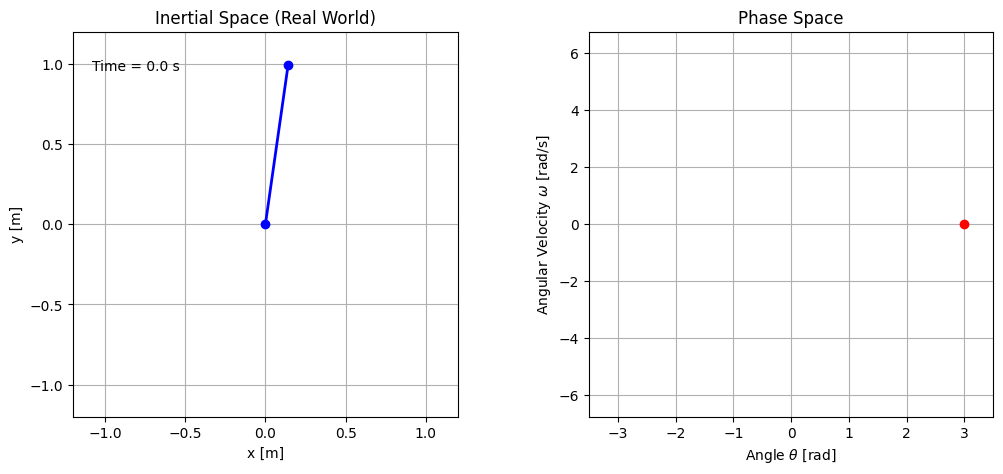

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import odeint

# --- パラメータ設定 ---
g = 9.81       # 重力加速度 [m/s^2]
L = 1.0        # 振り子の長さ [m]
m = 1.0        # おもりの質量 [kg] (運動方程式には影響しませんが概念として)
t_max = 20.0   # シミュレーション時間 [s]
dt = 0.05      # 時間刻み [s]

# 初期状態 [theta(ラジアン), omega(ラジアン/秒)]
# ※ ほぼ真上(3.14)に近い値にすると、ゆっくり動き出し、位相空間で「目」のような形が見えます
init_state = [3.0, 0.0] 

# --- 運動方程式の定義 ---
def pendulum_derivs(state, t, g, L):
    theta, omega = state
    dydt = [omega, -(g/L) * np.sin(theta)]
    return dydt

# --- 時間発展の計算 (ODEを解く) ---
t = np.arange(0, t_max, dt)
y = odeint(pendulum_derivs, init_state, t, args=(g, L))

theta = y[:, 0]
omega = y[:, 1]

# 直交座標系への変換（実空間プロット用）
x = L * np.sin(theta)
y_pos = -L * np.cos(theta)

# --- アニメーションの準備 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.3)

# 1. 実空間（左側）の設定
ax1.set_title('Inertial Space (Real World)')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [m]')
ax1.set_xlim(-L*1.2, L*1.2)
ax1.set_ylim(-L*1.2, L*1.2)
ax1.set_aspect('equal')
ax1.grid()

# 振り子のロッドとおもり
line, = ax1.plot([], [], 'o-', lw=2, color='blue')
time_text = ax1.text(0.05, 0.9, '', transform=ax1.transAxes)

# 2. 位相空間（右側）の設定
ax2.set_title('Phase Space')
ax2.set_xlabel(r'Angle $\theta$ [rad]')
ax2.set_ylabel(r'Angular Velocity $\omega$ [rad/s]')
ax2.set_xlim(np.min(theta)-0.5, np.max(theta)+0.5)
ax2.set_ylim(np.min(omega)-0.5, np.max(omega)+0.5)
ax2.grid()

# 軌跡と現在の点
traj, = ax2.plot([], [], '-', lw=1, color='green', alpha=0.5) # 軌跡
point, = ax2.plot([], [], 'o', color='red') # 現在の状態

# --- アニメーション更新関数 ---
def update(i):
    # 実空間の更新
    thisx = [0, x[i]]
    thisy = [0, y_pos[i]]
    line.set_data(thisx, thisy)
    time_text.set_text(f'Time = {t[i]:.1f} s')

    # 位相空間の更新
    # 過去の軌跡を表示
    traj.set_data(theta[:i+1], omega[:i+1])
    # 現在の点を表示
    point.set_data([theta[i]], [omega[i]])

    return line, time_text, traj, point

# アニメーションの作成
ani = animation.FuncAnimation(
    fig, update, frames=len(t), interval=dt*1000, blit=True
)

plt.show()

初期条件を計算中...
計算開始: 105 個の軌跡


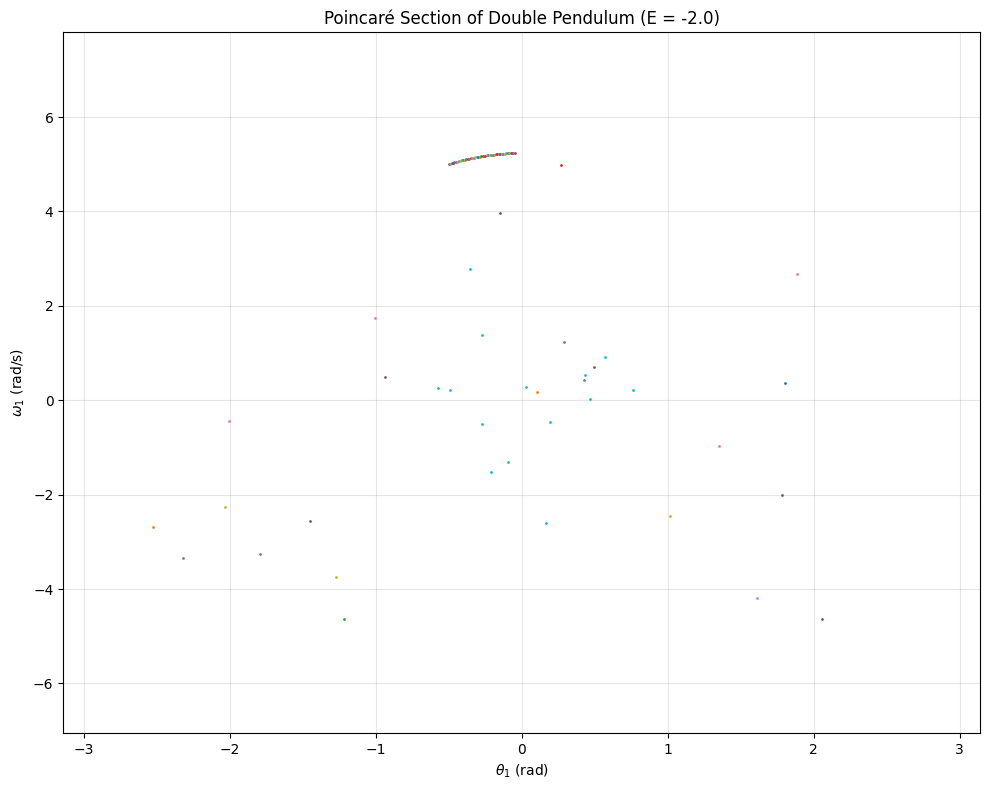

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- パラメータ設定 ---
g = 9.81   # 重力加速度
L1 = 1.0   # 1つ目の腕の長さ
L2 = 1.0   # 2つ目の腕の長さ
M1 = 1.0   # 1つ目の重りの質量
M2 = 1.0   # 2つ目の重りの質量

# ポアンカレ断面のエネルギーレベル (全エネルギー)
# ※ この値を大きくするとカオス領域が広がり、小さくすると秩序領域(トーラス)が増えます
# 基準: 最下点(安定平衡点)を0とした場合の位置エネルギーを含めた値
Target_Energy = -2.0 

# --- 運動方程式の定義 ---
def derivs(t, state):
    """
    state = [theta1, theta2, omega1, omega2]
    """
    th1, th2, w1, w2 = state
    dth = th1 - th2
    
    # 運動方程式の分母共通項
    den1 = (M1 + M2) * L1 - M2 * L1 * np.cos(dth) * np.cos(dth)
    den2 = (L2 / L1) * den1

    # omega1_dot
    eq1_num = (M2 * L1 * w1**2 * np.sin(dth) * np.cos(dth) +
               M2 * G * np.sin(th2) * np.cos(dth) +
               M2 * L2 * w2**2 * np.sin(dth) -
               (M1 + M2) * G * np.sin(th1))
    dw1 = eq1_num / den1

    # omega2_dot
    eq2_num = (-M2 * L2 * w2**2 * np.sin(dth) * np.cos(dth) +
               (M1 + M2) * G * np.sin(th1) * np.cos(dth) -
               (M1 + M2) * L1 * w1**2 * np.sin(dth) -
               (M1 + M2) * G * np.sin(th2))
    dw2 = eq2_num / den2

    return [w1, w2, dw1, dw2]

# --- エネルギー計算関数 ---
def calculate_energy(state):
    th1, th2, w1, w2 = state
    # 位置エネルギー (最上点を0とする標準的な定義、あとでオフセット可能)
    # ここでは y軸上向きを正として計算
    V = -M1*g*L1*np.cos(th1) - M2*g*(L1*np.cos(th1) + L2*np.cos(th2))
    
    # 運動エネルギー
    T = 0.5*(M1+M2)*L1**2*w1**2 + 0.5*M2*L2**2*w2**2 + M2*L1*L2*w1*w2*np.cos(th1-th2)
    
    return T + V

def solve_omega1_from_energy(theta1, theta2, omega2, E_target):
    """
    指定されたエネルギーになるような omega1 を逆算する
    (解なしの場合は None を返す)
    """
    # T + V = E -> T = E - V
    V = -M1*g*L1*np.cos(theta1) - M2*g*(L1*np.cos(theta1) + L2*np.cos(theta2))
    rem_E = E_target - V
    
    if rem_E < 0: return None # ポテンシャルが高すぎて到達不可能
    
    # Tは w1 の二次方程式: A*w1^2 + B*w1 + C = rem_E
    # 0.5*(M1+M2)*L1**2 * w1^2 + (M2*L1*L2*w2*cos(dth)) * w1 + (0.5*M2*L2**2*w2^2 - rem_E) = 0
    
    dth = theta1 - theta2
    A = 0.5 * (M1 + M2) * L1**2
    B = M2 * L1 * L2 * omega2 * np.cos(dth)
    C = 0.5 * M2 * L2**2 * omega2**2 - rem_E
    
    # 解の公式
    D = B**2 - 4*A*C
    if D < 0: return None
    
    w1_sol = (-B + np.sqrt(D)) / (2*A) # 正の解を採用
    return w1_sol

# --- イベント関数 (ポアンカレ断面の通過検知) ---
def section_event(t, state):
    # theta2 = 0 の瞬間を検知
    return state[1] 
section_event.direction = 1 # 負から正へ通過するときのみ (-1なら逆、0なら両方)
section_event.terminal = False

# --- メイン処理 ---
global G
G = g

# 初期条件のリスト作成
# theta2 = 0, omega2 = 0 (または固定) として、theta1 を変化させて走らせる
initial_theta1_list = np.linspace(-0.5, 0.5, 100) # 振り子の初期角度の範囲
initial_conditions = []

print("初期条件を計算中...")
for th1 in initial_theta1_list:
    # theta2=0, omega2=0 と仮定して、指定エネルギーになる w1 を探す
    # (こうすることで、同じエネルギー等高面上の軌道を比較できる)
    w1 = solve_omega1_from_energy(th1, 0.0, 0.0, Target_Energy)
    if w1 is not None:
        initial_conditions.append([th1, 0.0, w1, 0.0])

# カオス領域を強調するために、少しランダムな初期値も追加してみる
for _ in range(5):
     th1 = np.random.uniform(-1.0, 1.0)
     w1 = solve_omega1_from_energy(th1, 0.0, 0.0, Target_Energy)
     if w1 is not None:
        initial_conditions.append([th1, 0.0, w1, 0.0])


print(f"計算開始: {len(initial_conditions)} 個の軌跡")
plt.figure(figsize=(10, 8))

# 各初期値についてシミュレーション実行
for i, state0 in enumerate(initial_conditions):
    # 時間スパン (長くするほど点は増える)
    t_span = (0, 1000) 
    
    # 計算実行 (rtol, atolは精度確保のため小さめに)
    sol = solve_ivp(derivs, t_span, state0, events=section_event, 
                    rtol=1e-9, atol=1e-9, method='DOP853')
    
    # イベント発生時の状態を取得
    if len(sol.t_events[0]) > 0:
        # section_states shape: (n_events, 4)
        states_at_section = sol.y_events[0] 
        
        # プロット: 横軸 theta1, 縦軸 omega1
        # (theta2=0 の瞬間の theta1 と omega1 をプロット)
        plt.plot(states_at_section[:, 0], states_at_section[:, 2], '.', markersize=2)

plt.title(f'Poincaré Section of Double Pendulum (E = {Target_Energy})')
plt.xlabel(r'$\theta_1$ (rad)')
plt.ylabel(r'$\omega_1$ (rad/s)')
plt.grid(True, alpha=0.3)
plt.xlim(-3.14, 3.14)
plt.tight_layout()
plt.show()

Computing Poincare Section for Earth-Moon (mu=0.01215), C=3.17
Simulating 60/60: x0=0.9500
Done.


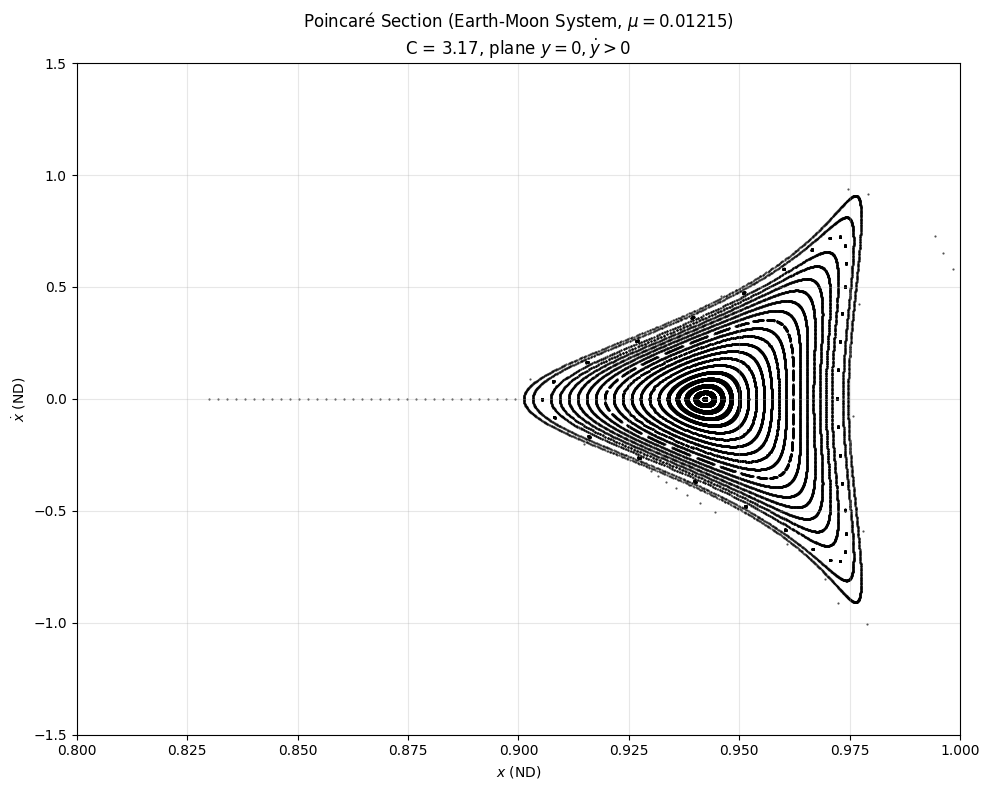

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- パラメータ設定 (地球-月系) ---
# この質量比だとカオスが明確に出現します
mu = 0.01215 

# ヤコビ定数 C
# L1点(約3.188)よりわずかに低いエネルギーに設定し、L1付近のゲートを開く
C_target = 3.17 

# --- 運動方程式 (CR3BP) ---
def equations(t, state, mu):
    x, y, vx, vy = state
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    
    Om_x = x - (1 - mu) * (x + mu) / r1**3 - mu * (x - (1 - mu)) / r2**3
    Om_y = y - (1 - mu) * y / r1**3 - mu * y / r2**3
    
    ax = 2 * vy + Om_x
    ay = -2 * vx + Om_y
    return [vx, vy, ax, ay]

# --- イベント1: ポアンカレ断面 (y=0, vy>0) ---
def event_poincare(t, state, mu):
    return state[1] # y
event_poincare.direction = 1 
event_poincare.terminal = False # 断面通過時は停止しない

# --- イベント2: 月への衝突 (特異点回避) ---
def event_collision(t, state, mu):
    x, y, _, _ = state
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    return r2 - 0.005 # 月の中心から一定距離以内なら停止
event_collision.terminal = True

# --- ヤコビ定数から vy を計算 ---
def get_vy_from_C(x, y, vx, C, mu):
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    Omega = 0.5 * (x**2 + y**2) + (1 - mu)/r1 + mu/r2
    term = 2 * Omega - C - vx**2
    if term < 0: return None
    return np.sqrt(term)

# --- メイン処理 ---
def main():
    print(f"Computing Poincare Section for Earth-Moon (mu={mu}), C={C_target}")
    
    # 月(1-mu)の左側、L1点付近を重点的にスキャン
    # x座標: 0.82 (地球寄り) ～ 0.98 (月直前)
    x_start_points = np.linspace(0.83, 0.95, 60)
    
    plt.figure(figsize=(10, 8))
    
    # プロット用のリスト
    all_px = []
    all_pvx = []

    for i, x0 in enumerate(x_start_points):
        # 進捗表示
        print(f"\rSimulating {i+1}/{len(x_start_points)}: x0={x0:.4f}", end="")
        
        y0 = 0.0
        vx0 = 0.0
        vy0 = get_vy_from_C(x0, y0, vx0, C_target, mu)
        
        if vy0 is None: continue

        state0 = [x0, y0, vx0, vy0]
        
        # 時間を長くする (t=0 to 1000) ことで構造を浮かび上がらせる
        t_span = (0, 1000)
        
        sol = solve_ivp(
            equations, t_span, state0, args=(mu,),
            events=[event_poincare, event_collision],
            rtol=1e-10, atol=1e-10, # 精度をさらに厳しく
            max_step=0.05
        )
        
        # event_poincare (index 0) の結果を取得
        if len(sol.t_events[0]) > 0:
            crossings = sol.y_events[0]
            px = crossings[:, 0]
            pvx = crossings[:, 2]
            
            # 外れ値（速度が発散している点）を除外してプロット
            mask = np.abs(pvx) < 2.0 
            plt.scatter(px[mask], pvx[mask], s=0.3, c='black', alpha=0.7)

    print("\nDone.")
    
    plt.title(f'Poincaré Section (Earth-Moon System, $\mu={mu}$)\nC = {C_target}, plane $y=0, \dot{{y}}>0$')
    plt.xlabel('$x$ (ND)')
    plt.ylabel('$\dot{x}$ (ND)')
    plt.xlim(0.8, 1.0)  # 月周辺を表示
    plt.ylim(-1.5, 1.5) # 速度の発散部分はカット
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Target C: 3.0002
L1 approx location: 0.989997
Simulating...
Progress: 0/100


KeyboardInterrupt: 

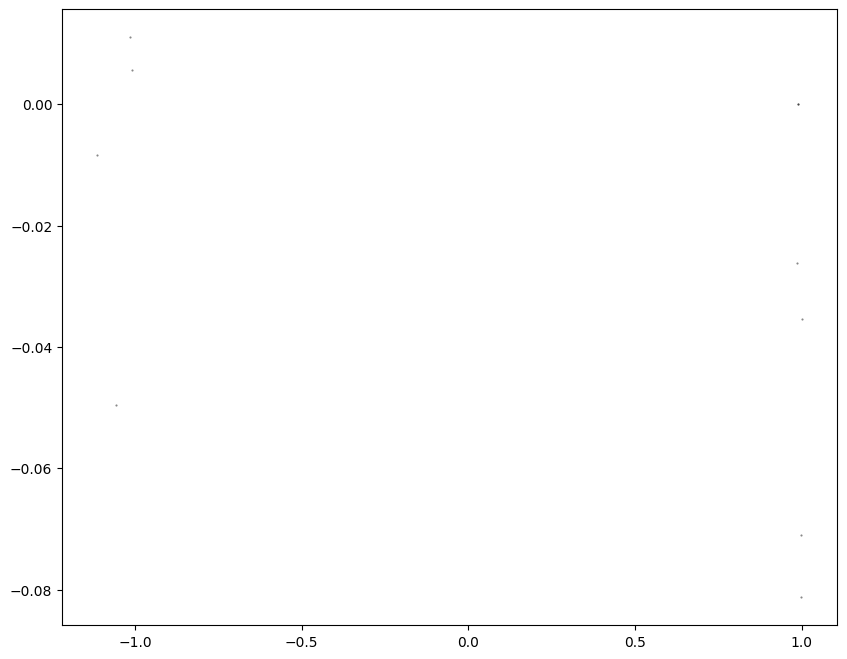

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- パラメータ設定 (太陽-地球系) ---
mu = 3.003e-6  # 太陽-地球の質量比

# L1点の位置近似 (Hill半径に基づく)
r_L1 = (mu/3)**(1/3)
x_L1 = 1 - r_L1  # 約 0.9900

# ★重要★ ヤコビ定数 C
# L1点におけるC値(約3.0009)の「直下」を狙います。
# エネルギーが高すぎると(Cが小さいと)ただの通過軌道になり、
# エネルギーが低すぎると(Cが大きいと)閉じ込められます。
# この値の微調整がカオス可視化の命です。
C_target = 3.0002

print(f"Target C: {C_target}")
print(f"L1 approx location: {x_L1:.6f}")

# --- 運動方程式 (CR3BP) ---
def equations(t, state, mu):
    x, y, vx, vy = state
    r1 = ((x + mu)**2 + y**2)**1.5
    r2 = ((x - (1 - mu))**2 + y**2)**1.5
    
    ax = 2*vy + x - (1-mu)*(x+mu)/r1 - mu*(x-(1-mu))/r2
    ay = -2*vx + y - (1-mu)*y/r1 - mu*y/r2
    return [vx, vy, ax, ay]

# --- イベント: y=0 面通過 ---
def event_poincare(t, state, mu):
    return state[1]
event_poincare.direction = 1 # 負から正へ
event_poincare.terminal = False

# --- イベント: 領域外への脱出（計算打ち切り用） ---
def event_escape(t, state, mu):
    x, y, _, _ = state
    # 太陽に近づきすぎ or 地球から離れすぎ or 地球衝突
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    if r2 < 1e-4: return -1 # 地球衝突
    if abs(x) > 1.2: return -1 # 遠方へ脱出
    return 1.0
event_escape.terminal = True

# --- 初期速度 vy の計算 ---
def get_vy(x, C, mu):
    y = 0
    vx = 0
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    Omega = 0.5*(x**2 + y**2) + (1-mu)/r1 + mu/r2
    v2 = 2*Omega - C
    if v2 < 0: return None
    return np.sqrt(v2)

# --- メイン処理 ---
def main():
    # スキャン範囲: 地球(1.0)とL1(0.99)の間にある「ハロー軌道」の存在領域
    # ここにカオスの「海」と安定な「島」が混在します
    x_values = np.linspace(0.988, 0.998, 100)
    
    plt.figure(figsize=(10, 8))
    
    print("Simulating...")
    for i, x0 in enumerate(x_values):
        vy0 = get_vy(x0, C_target, mu)
        if vy0 is None: continue
        
        # 時間を十分長くとる
        # 太陽-地球系は周期が長いため、無次元時間で300くらい回さないと構造が見えません
        sol = solve_ivp(equations, [0, 300], [x0, 0, 0, vy0], 
                        args=(mu,), events=[event_poincare, event_escape],
                        rtol=1e-11, atol=1e-11, max_step=0.01) # 精度重視
        
        if len(sol.t_events[0]) > 0:
            # ポアンカレ写像の点をプロット
            ys = sol.y_events[0]
            plt.plot(ys[:, 0], ys[:, 2], '.', markersize=1, color='black', alpha=0.5)
            
        if i % 10 == 0: print(f"Progress: {i}/{len(x_values)}")

    plt.title(f'Poincaré Section (Sun-Earth), C={C_target}\nFocus: Near L1 Point (Chaos Edge)')
    plt.xlabel('x (ND)')
    plt.ylabel('vx (ND)')
    # 描画範囲をL1〜地球付近に限定
    plt.xlim(0.985, 1.005)
    plt.ylim(-0.02, 0.02) # 速度も微小領域
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    main()

Target C: 3.0006
Generating Poincare Map...
Scanning: 0/100
Scanning: 20/100
Scanning: 40/100
Scanning: 60/100
Scanning: 80/100
Simulating detailed orbit for Periodic-like...
Simulating detailed orbit for Chaotic...


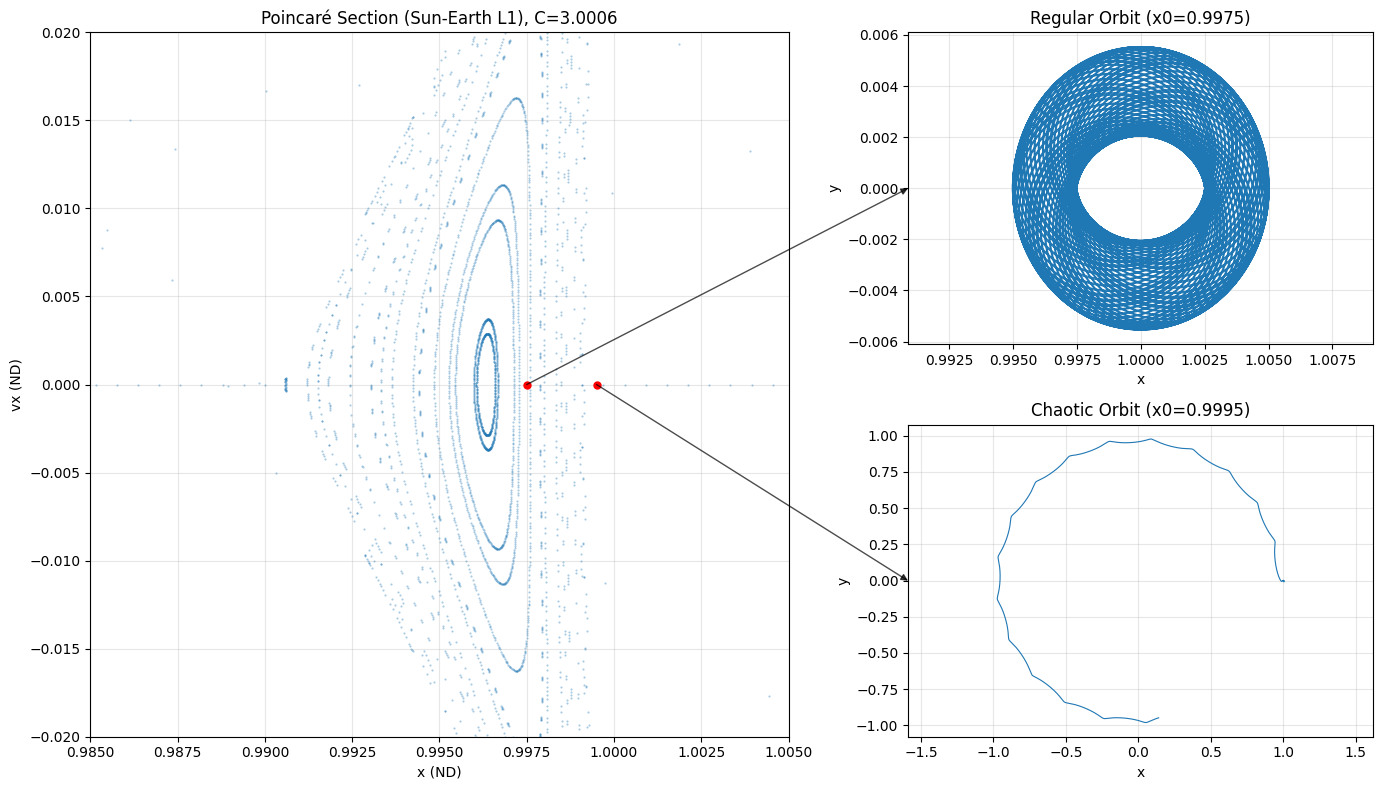

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch
from scipy.integrate import solve_ivp

# --- パラメータ設定 (太陽-地球系) ---
mu = 3.003e-6  # 太陽-地球の質量比
C_target = 3.0006 # ヤコビ定数

# ★ここに注目したいx座標を指定します★
# 1. 規則軌道 (Periodic/Quasi-periodic) の候補
x_target_periodic = 0.9975

# 2. カオス軌道 (Chaotic) の候補
x_target_chaotic = 0.9995

print(f"Target C: {C_target}")

# --- 運動方程式 (CR3BP) ---
def equations(t, state, mu):
    x, y, vx, vy = state
    r1 = ((x + mu)**2 + y**2)**1.5
    r2 = ((x - (1 - mu))**2 + y**2)**1.5
    
    ax = 2*vy + x - (1-mu)*(x+mu)/r1 - mu*(x-(1-mu))/r2
    ay = -2*vx + y - (1-mu)*y/r1 - mu*y/r2
    return [vx, vy, ax, ay]

# --- イベント: y=0 面通過 ---
def event_poincare(t, state, mu):
    return state[1]
event_poincare.direction = 1 # 負から正へ (y=0を上に抜ける時)
event_poincare.terminal = False

# --- イベント: 領域外への脱出（計算打ち切り用） ---
def event_escape(t, state, mu):
    x, y, _, _ = state
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    if r2 < 1e-12: return -1 # 地球衝突
    # if abs(x) > 1.2: return -1 # 遠方へ脱出
    return 1.0
event_escape.terminal = True

# --- 初期速度 vy の計算 ---
def get_vy(x, C, mu):
    y = 0
    vx = 0
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    Omega = 0.5*(x**2 + y**2) + (1-mu)/r1 + mu/r2
    v2 = 2*Omega - C
    if v2 < 0: return None
    return np.sqrt(v2)

# --- プロット用のヘルパー関数 ---
def run_simulation(x0, t_max=300):
    """指定されたx0でシミュレーションを実行し、解とイベントを返す"""
    vy0 = get_vy(x0, C_target, mu)
    if vy0 is None: return None, None
    
    sol = solve_ivp(equations, [0, t_max], [x0, 0, 0, vy0], 
                    args=(mu,), events=[event_poincare, event_escape],
                    rrtol=1e-11, atol=1e-11, max_step=0.01)
    return sol, vy0

def main():
    # --- フォントサイズの一括設定 (ここを追加) ---
    plt.rcParams.update({
        'font.size': 14,          # 全体の基本フォントサイズ
        'axes.titlesize': 16,     # グラフタイトルのサイズ
        'axes.labelsize': 16,     # 軸ラベル(xlabel, ylabel)のサイズ
        'xtick.labelsize': 12,    # x軸目盛りの数字サイズ
        'ytick.labelsize': 12,    # y軸目盛りの数字サイズ
        'figure.titlesize': 20    # 全体タイトルのサイズ
    })

    # --- キャンバス設定 ---
    fig = plt.figure(figsize=(14, 8))
    # レイアウト: 左側に大きなマップ、右側に上下2つの軌道図
    gs = GridSpec(2, 2, width_ratios=[1.5, 1]) 
    
    ax_map = fig.add_subplot(gs[:, 0])      # 左: ポアンカレマップ
    ax_orbit1 = fig.add_subplot(gs[0, 1])   # 右上: 規則軌道
    ax_orbit2 = fig.add_subplot(gs[1, 1])   # 右下: カオス軌道

    # -------------------------------------------------------
    # 1. ポアンカレマップの生成 (背景)
    # -------------------------------------------------------
    x_values = np.linspace(0.97, 1.03, 100) # 少し荒くして高速化
    
    print("Generating Poincare Map...")
    for i, x0 in enumerate(x_values):
        sol, _ = run_simulation(x0, t_max=300)
        if sol is None: continue

        if len(sol.t_events[0]) > 0:
            ys = sol.y_events[0]
            # 横軸: x, 縦軸: vx (画像(d)に対応)
            ax_map.plot(ys[:, 0], ys[:, 2], '.', markersize=1, color='tab:blue', alpha=0.4)
        
        if i % 20 == 0: print(f"Scanning: {i}/{len(x_values)}")

    # -------------------------------------------------------
    # 2. 特定軌道の描画と矢印の接続
    # -------------------------------------------------------
    targets = [
        # (x座標, ラベル, 描画先Axes, タイトル)
        (x_target_periodic, "Periodic-like", ax_orbit1, f"Regular Orbit (x0={x_target_periodic})"),
        (x_target_chaotic,  "Chaotic",       ax_orbit2, f"Chaotic Orbit (x0={x_target_chaotic})")
    ]

    for x_tgt, label, ax_orb, title in targets:
        print(f"Simulating detailed orbit for {label}...")
        sol, vy0 = run_simulation(x_tgt, t_max=100) # 軌道が見やすい長さ
        
        if sol is not None:
            # A. マップ上に強調点をプロット
            p_point, = ax_map.plot(x_tgt, 0, 'o', color='red', markersize=5, zorder=10)
            
            # B. 実軌道 (x-y) をプロット
            ax_orb.plot(sol.y[0], sol.y[1], linewidth=0.8)
            ax_orb.set_title(title)
            ax_orb.set_xlabel('x')
            ax_orb.set_ylabel('y')
            ax_orb.axis('equal') # 軌道の形状を正しく見るため
            ax_orb.grid(True, alpha=0.3)

            # C. 矢印を描画 (ConnectionPatch)
            con = ConnectionPatch(xyA=(x_tgt, 0), coordsA=ax_map.transData,
                                  xyB=(0, 0.5), coordsB=ax_orb.transAxes, # 右図の左端中央へ
                                  arrowstyle="-|>", color="black", alpha=0.7, lw=1.5) # 矢印も少し太くしました
            fig.add_artist(con)

    # -------------------------------------------------------
    # 装飾設定
    # -------------------------------------------------------
    ax_map.set_title(f'Poincaré Section (Sun-Earth L1), C={C_target}')
    ax_map.set_xlabel('x (ND)')
    ax_map.set_ylabel('vx (ND)') 
    ax_map.set_xlim(0.985, 1.005)
    ax_map.set_ylim(-0.02, 0.02)
    ax_map.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Target C: 3.0005
Generating Phase Space Map...
Scanning: 0/90
Scanning: 20/90
Scanning: 40/90
Scanning: 60/90
Scanning: 80/90
Simulating: Stable Capture Region (Quasi-Periodic)...
Simulating: Chaotic Diffusion (Risk Area)...


C:\Users\thayb\AppData\Local\Temp\ipykernel_41260\2503886060.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


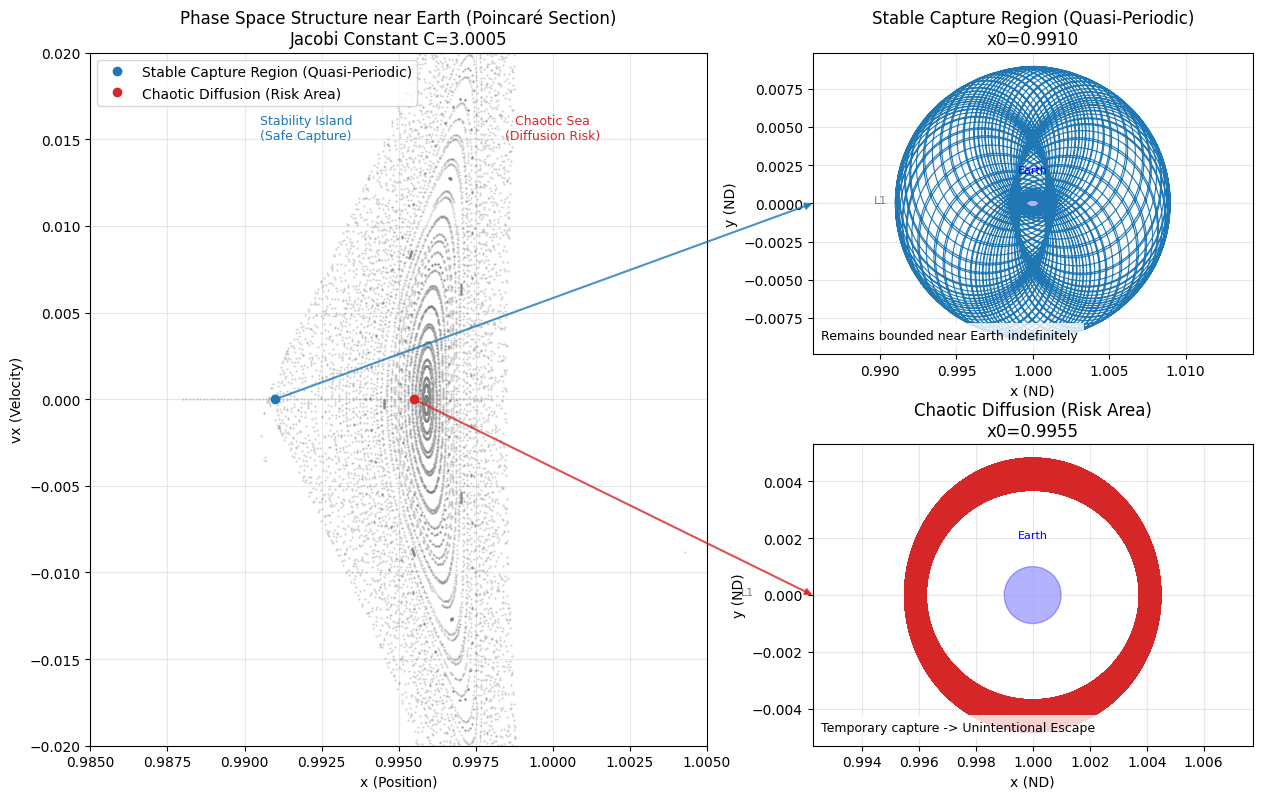

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch, Circle
from scipy.integrate import solve_ivp

# --- パラメータ設定 (太陽-地球系) ---
mu = 3.003e-6  # 太陽-地球の質量比
C_target = 3.0005 # ヤコビ定数 (L1のボトルネックが開いている状態)

# ★論文/発表用のストーリーを作るためのターゲット座標★
# 1. 安定捕獲領域 (Stable Quasi-Periodic Orbit)
#    島の内側。いつまでも地球近傍のトーラスに留まる。
x_target_stable = 0.9910 

# 2. カオス的拡散/再離脱 (Chaotic Diffusion / Escape)
#    島の境界付近。最初は捕獲されているが、後に拡散して太陽方向へ逃げる。
x_target_diffusion = 0.9955

print(f"Target C: {C_target}")

# --- 運動方程式 (CR3BP) ---
def equations(t, state, mu):
    x, y, vx, vy = state
    r1 = ((x + mu)**2 + y**2)**1.5
    r2 = ((x - (1 - mu))**2 + y**2)**1.5
    
    ax = 2*vy + x - (1-mu)*(x+mu)/r1 - mu*(x-(1-mu))/r2
    ay = -2*vx + y - (1-mu)*y/r1 - mu*y/r2
    return [vx, vy, ax, ay]

# --- イベント定義 ---
def event_poincare(t, state, mu):
    return state[1]
event_poincare.direction = 1 
event_poincare.terminal = False

def event_escape(t, state, mu):
    x, y, _, _ = state
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    if r2 < 1e-4: return -1 # 地球衝突
    # if abs(x) > 1.1: return -1 # 拡散（描画範囲外へ）
    return 1.0
event_escape.terminal = True

# --- 初期速度 vy の計算 ---
def get_vy(x, C, mu):
    y = 0
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    Omega = 0.5*(x**2 + y**2) + (1-mu)/r1 + mu/r2
    v2 = 2*Omega - C
    if v2 < 0: return None
    return np.sqrt(v2)

# --- シミュレーション実行 ---
def run_simulation(x0, t_max=300):
    vy0 = get_vy(x0, C_target, mu)
    if vy0 is None: return None, None
    
    # カオス的拡散を見せるため、精度を高く保つ
    sol = solve_ivp(equations, [0, t_max], [x0, 0, 0, vy0], 
                    args=(mu,), events=[event_poincare, event_escape],
                    rtol=1e-12, atol=1e-12, max_step=0.01)
    return sol, vy0

def main():
    # --- キャンバス設定 ---
    fig = plt.figure(figsize=(15, 9))
    gs = GridSpec(2, 2, width_ratios=[1.4, 1], wspace=0.2, hspace=0.3) 
    
    ax_map = fig.add_subplot(gs[:, 0])      # 左: 位相空間構造
    ax_orbit1 = fig.add_subplot(gs[0, 1])   # 右上: 安定領域
    ax_orbit2 = fig.add_subplot(gs[1, 1])   # 右下: カオス的拡散

    # -------------------------------------------------------
    # 1. 位相空間の構造 (Poincaré Map)
    # -------------------------------------------------------
    # スキャン範囲: L1点(約0.99)から地球(1.0)の間にある構造
    x_values = np.linspace(0.988, 0.998, 90) 
    
    print("Generating Phase Space Map...")
    for i, x0 in enumerate(x_values):
        sol, _ = run_simulation(x0, t_max=200)
        if sol is None: continue
        if len(sol.t_events[0]) > 0:
            ys = sol.y_events[0]
            ax_map.plot(ys[:, 0], ys[:, 2], '.', markersize=0.8, color='gray', alpha=0.5)
        if i % 20 == 0: print(f"Scanning: {i}/{len(x_values)}")

    # -------------------------------------------------------
    # 2. 比較軌道の描画
    # -------------------------------------------------------
    targets = [
        {
            "x": x_target_stable, 
            "ax": ax_orbit1, 
            "color": "tab:blue",
            "title": "Stable Capture Region (Quasi-Periodic)",
            "desc": "Remains bounded near Earth indefinitely",
            "t_max": 150
        },
        {
            "x": x_target_diffusion, 
            "ax": ax_orbit2, 
            "color": "tab:red",
            "title": "Chaotic Diffusion (Risk Area)",
            "desc": "Temporary capture -> Unintentional Escape",
            "t_max": 300 # 拡散する様子を見るため長めに
        }
    ]

    for item in targets:
        x_tgt = item["x"]
        ax = item["ax"]
        print(f"Simulating: {item['title']}...")
        
        sol, _ = run_simulation(x_tgt, t_max=item["t_max"])
        
        if sol is not None:
            # マップ上の位置
            ax_map.plot(x_tgt, 0, 'o', color=item["color"], markersize=6, zorder=10, label=item["title"])
            
            # 軌道描画
            ax.plot(sol.y[0], sol.y[1], linewidth=0.8, color=item["color"])
            
            # 地球の描画 (縮尺はイメージ)
            earth = Circle((1-mu, 0), 0.001, color='blue', alpha=0.3, label='Earth')
            ax.add_patch(earth)
            ax.text(1-mu, 0.002, "Earth", color='blue', ha='center', fontsize=8)

            # L1点の目安
            ax.text(0.99, 0, "L1", color='black', ha='center', fontsize=8, alpha=0.5)

            ax.set_title(f"{item['title']}\nx0={x_tgt:.4f}")
            ax.set_xlabel('x (ND)')
            ax.set_ylabel('y (ND)')
            ax.axis('equal')
            ax.grid(True, alpha=0.3)
            
            # 説明テキスト
            ax.text(0.02, 0.05, item["desc"], transform=ax.transAxes, 
                    fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

            # 矢印
            con = ConnectionPatch(xyA=(x_tgt, 0), coordsA=ax_map.transData,
                                  xyB=(0, 0.5), coordsB=ax.transAxes,
                                  arrowstyle="-|>", color=item["color"], alpha=0.8, lw=1.5)
            fig.add_artist(con)

    # -------------------------------------------------------
    # マップの装飾
    # -------------------------------------------------------
    ax_map.set_title(f'Phase Space Structure near Earth (Poincaré Section)\nJacobi Constant C={C_target}')
    ax_map.set_xlabel('x (Position)')
    ax_map.set_ylabel('vx (Velocity)')
    ax_map.set_xlim(0.985, 1.005)
    ax_map.set_ylim(-0.02, 0.02)
    ax_map.grid(True, alpha=0.3)
    ax_map.legend(loc='upper left')

    # 論文用の注釈
    ax_map.text(0.992, 0.015, "Stability Island\n(Safe Capture)", ha='center', fontsize=9, color='tab:blue')
    ax_map.text(1.000, 0.015, "Chaotic Sea\n(Diffusion Risk)", ha='center', fontsize=9, color='tab:red')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()